# Assignemt 01 - Sentiment Analysis

<details>
  <summary><span style="font-size:1.5em; font-weight:bold; color:#1f77b4;">Problem Statement</span></summary>

  <p>

### Sentiment Analysis Using TF-IDF Vectors

**Objective:**  
Design and implement a machine learning model to perform sentiment analysis on a given dataset containing textual data and corresponding sentiment labels. The analysis should use **TF-IDF (Term Frequency-Inverse Document Frequency)** vectors to transform the text into numerical features and classify the sentiments effectively.

### Dataset Description for Sentiment Analysis Project

**Content:**  
The dataset is stored in a **CSV file** and includes six fields:

1. **Polarity (Column 0):**  
   - Sentiment label for the tweet:  
     - `0`: Negative sentiment  
     - `2`: Neutral sentiment  
     - `4`: Positive sentiment

2. **Tweet ID (Column 1):**  
   - A unique identifier for each tweet.

3. **Date (Column 2):**  
   - The timestamp of when the tweet was posted, in the format:  
     `Day Month Date HH:MM:SS UTC Year`  
     *(e.g., Sat May 16 23:58:44 UTC 2009)*

4. **Query (Column 3):**  
   - The search query used to retrieve the tweet.  
     If no query was used, the value is `NO_QUERY`.

5. **User (Column 4):**  
   - The username of the account that posted the tweet  
     *(e.g., robotickilldozr)*

6. **Text (Column 5):**  
   - The content of the tweet, consisting of raw text after emoticons have been removed  
     *(e.g., Lyx is cool)*

Dataset Source on Kaggle
  </p>
</details>

## To Do List

- [ ] Try to change a bit in the neural network, to see if we can get better accuracies.
- [ ] Do a better evaluation, some confusion matrix and balanced accuracy.
- [ ] change validation to test ka name
- [ ] ballesh tobyid ... the text and explanation... COPILOTEH.

## Imports

In [1]:
# import kagglehub
import pandas as pd
import html
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Download NLTK resources if needed
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('tokenizers/punkt_tab')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('stopwords')
    nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abarhouche\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abarhouche\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abarhouche\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abarhouche\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Read + EDA

In [45]:
train_df = pd.read_csv("../Data/train_data.csv", encoding="Windows-1252")
train_df.rename(
    columns={
        'polarity of tweet\xa0' : 'polarity',
        'text of the tweet\xa0' : 'text'
    },
    inplace = True
)

In [46]:
train_df.head()

,polarity,id of the tweet,date of the tweet,query,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


focus only on necessary info

In [47]:
train_df = train_df[["text", "polarity"]]

print(f"train has {len(train_df)} rows")

train has 1048572 rows


check for Nans

In [48]:
print("train Nans")
print(train_df.isnull().sum())

train Nans
text        0
polarity    0
dtype: int64


In [49]:
before = len(train_df)
train_df.dropna(how="any", inplace=True)
print(f"{before - len(train_df)} NaN rows dropped.")

0 NaN rows dropped.


do basic text cleaning

In [50]:
def basic_text_clean(text):
    text = html.unescape(text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    text = text.strip()
    return text

In [51]:
train_df["text"] = train_df["text"].apply(basic_text_clean)

check for duplicates

In [52]:
has_duplicates = train_df.duplicated().any()
print("train_df has duplicates:", has_duplicates)

train_df has duplicates: True


clean duplicates after clean text ... leads to more rows dropped

In [53]:
before = len(train_df)
train_df.drop_duplicates(inplace=True)
print(f"{before - len(train_df)} rows are dropped")

15020 rows are dropped


In [54]:
print(f"train has {len(train_df)} rows")

train has 1033552 rows


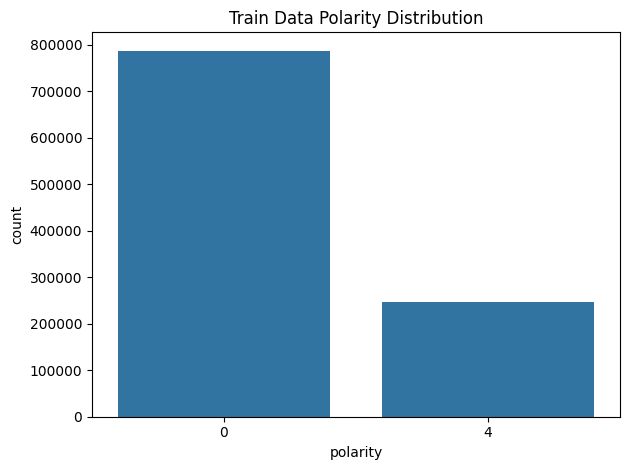

In [58]:
# Train data polarity distribution
sns.countplot(data=train_df, x="polarity")
plt.title("Train Data Polarity Distribution")

plt.tight_layout()

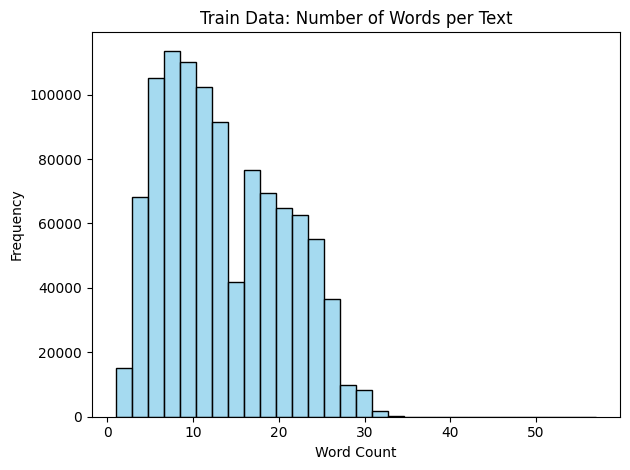

In [61]:
# Calculate word counts
train_word_counts = train_df['text'].astype(str).apply(lambda x: len(x.split()))

sns.histplot(train_word_counts, bins=30, color='skyblue')
plt.title('Train Data: Number of Words per Text')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()

## TF-IDF

In [62]:
import string 

def text_preprocess(text):
    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove hashtags (keeping the text after #)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # Join tokens back into text
    text = ' '.join(tokens)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation)).strip()
    return text

In [63]:
train_df["text"] = train_df["text"].apply(text_preprocess)

### Train - Test Split

In [64]:
from sklearn.model_selection import train_test_split

X = train_df[["text"]]
y = train_df[["polarity"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, shuffle=True, stratify=train_df["polarity"])

In [69]:
y_train.values.flatten()

array([0, 0, 4, ..., 0, 0, 0], dtype=int64)

<AxesSubplot:ylabel='count'>

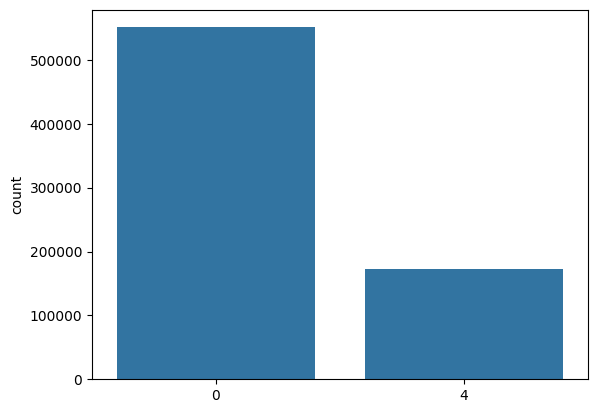

In [70]:
sns.countplot(x=y_train.values.flatten())

<AxesSubplot:ylabel='count'>

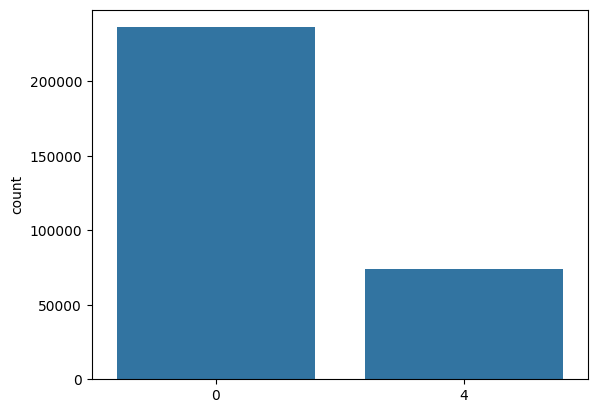

In [71]:
sns.countplot(x=y_test.values.flatten())

In [72]:
tfidf_ngram_vectorizer = TfidfVectorizer(min_df=0.001, ngram_range=(1, 3), max_features=2048)
tfidf_ngram_vectorizer_train = tfidf_ngram_vectorizer.fit_transform(X_train["text"])
tfidf_ngram_vectorizer_test = tfidf_ngram_vectorizer.transform(X_test["text"])
tfidf_ngram_vectorizer.get_feature_names_out()[150:160]

array(['card', 'care', 'case', 'cat', 'catch', 'caught', 'cause', 'cd',
       'chance', 'change'], dtype=object)

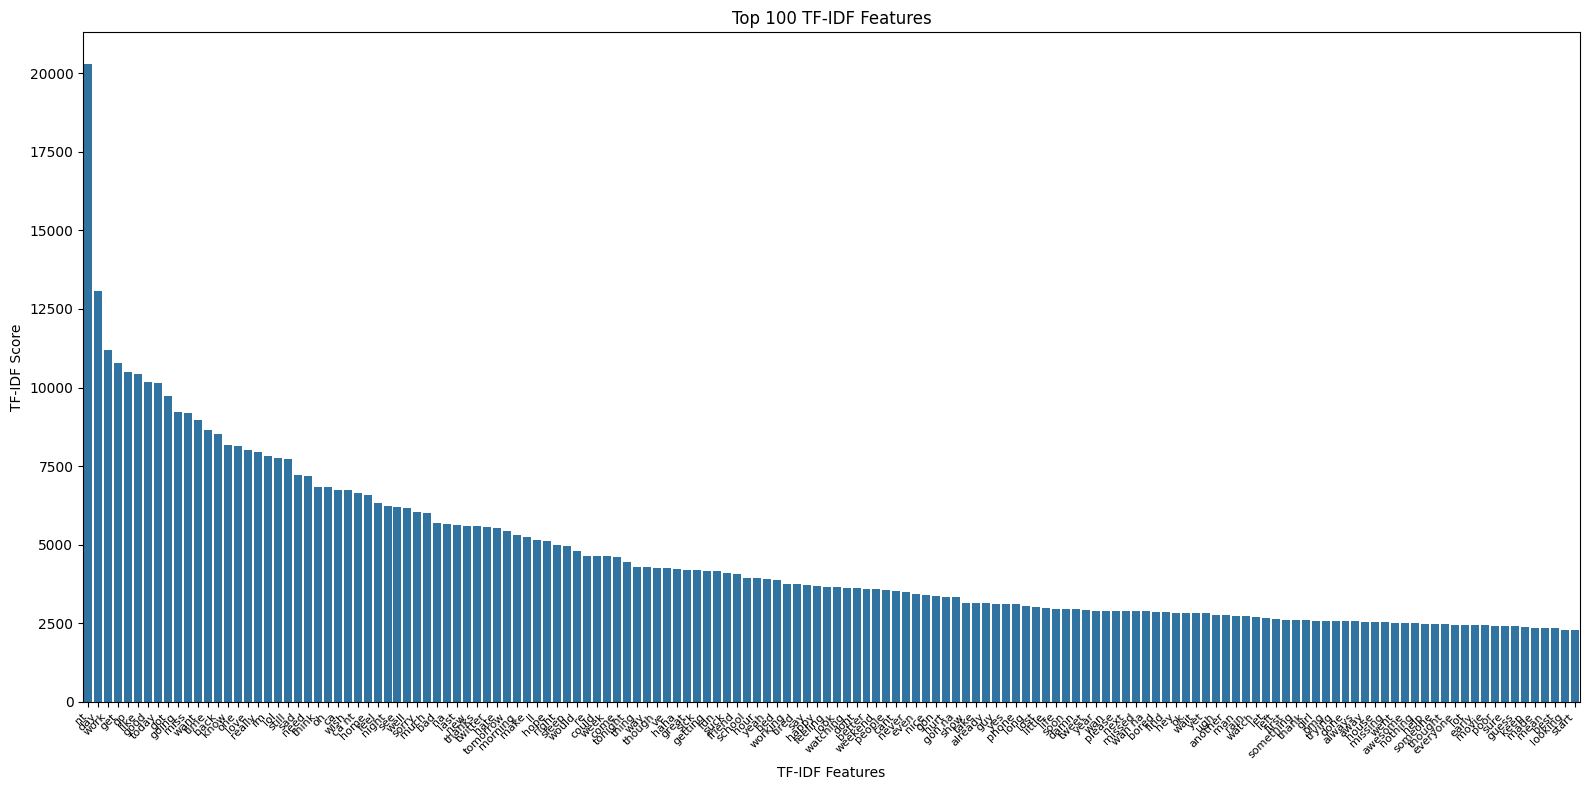

In [73]:

# Get feature names and summed TF-IDF values
feature_array = tfidf_ngram_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_ngram_vectorizer_train.sum(axis=0).A1
tfidf_freq_df = pd.DataFrame({'feature': feature_array, 'tfidf_sum': tfidf_scores})


feature_scores = pd.DataFrame({'feature': feature_array, 'score': tfidf_scores})

# Get top 100 features by score
top_features = feature_scores.nlargest(150, 'score')

# Plot using seaborn with flipped axes and rotated x-axis labels
plt.figure(figsize=(16, 8))
sns.barplot(data=top_features, x='feature', y='score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.xlabel("TF-IDF Features")
plt.ylabel("TF-IDF Score")
plt.title("Top 100 TF-IDF Features")
plt.tight_layout()
plt.savefig("top_100_tfidf_features_flipped.png")
plt.show()



In [74]:
train_vectors = tfidf_ngram_vectorizer_train.toarray()
print(train_vectors.shape)
test_vectors = tfidf_ngram_vectorizer_test.toarray()
print(test_vectors.shape)

(723486, 1138)
(310066, 1138)


In [75]:
# converting the features_train and features_validation 
train_vectors = torch.tensor(train_vectors, dtype=torch.float32)
test_vectors = torch.tensor(test_vectors, dtype=torch.float32)

## Model + Training + Eval

In [76]:
train_vectors.shape

torch.Size([723486, 1138])

In [77]:
# convert target variables into pytorch tensors
label_map = {0: 0, 4: 1}

y_train = torch.tensor(y_train["polarity"].map(label_map).to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test["polarity"].map(label_map).to_numpy(), dtype=torch.long)

In [78]:
y_train.shape
y_test.shape

torch.Size([310066])

In [79]:
# initialise TensorDataset  object
train_dataset = TensorDataset(train_vectors, y_train)
val_dataset = TensorDataset(test_vectors, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=True)

In [80]:
class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size=16, output_size=2, dropout_rate=0.43):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, output_size)
        # No activation here; use CrossEntropyLoss during training

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out  # raw logits

In [81]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [82]:
num_epochs = 30  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs
        val_loss = criterion(val_outputs, labels)
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

Epoch 1/30, Loss: 0.4343, Val Loss: 0.4118
Epoch 2/30, Loss: 0.4105, Val Loss: 0.4108
Epoch 3/30, Loss: 0.4094, Val Loss: 0.4105
Epoch 4/30, Loss: 0.4087, Val Loss: 0.4107
Epoch 5/30, Loss: 0.4085, Val Loss: 0.4101
Epoch 6/30, Loss: 0.4078, Val Loss: 0.4101
Epoch 7/30, Loss: 0.4076, Val Loss: 0.4098
Epoch 8/30, Loss: 0.4075, Val Loss: 0.4105
Epoch 9/30, Loss: 0.4070, Val Loss: 0.4104
Epoch 10/30, Loss: 0.4069, Val Loss: 0.4097
Epoch 11/30, Loss: 0.4067, Val Loss: 0.4099
Epoch 12/30, Loss: 0.4063, Val Loss: 0.4101
Epoch 13/30, Loss: 0.4064, Val Loss: 0.4101
Epoch 14/30, Loss: 0.4060, Val Loss: 0.4104
Epoch 15/30, Loss: 0.4064, Val Loss: 0.4099
Epoch 16/30, Loss: 0.4059, Val Loss: 0.4096
Epoch 17/30, Loss: 0.4059, Val Loss: 0.4102
Epoch 18/30, Loss: 0.4057, Val Loss: 0.4103
Epoch 19/30, Loss: 0.4053, Val Loss: 0.4098
Epoch 20/30, Loss: 0.4053, Val Loss: 0.4103
Epoch 21/30, Loss: 0.4054, Val Loss: 0.4097
Epoch 22/30, Loss: 0.4051, Val Loss: 0.4094
Epoch 23/30, Loss: 0.4050, Val Loss: 0.41

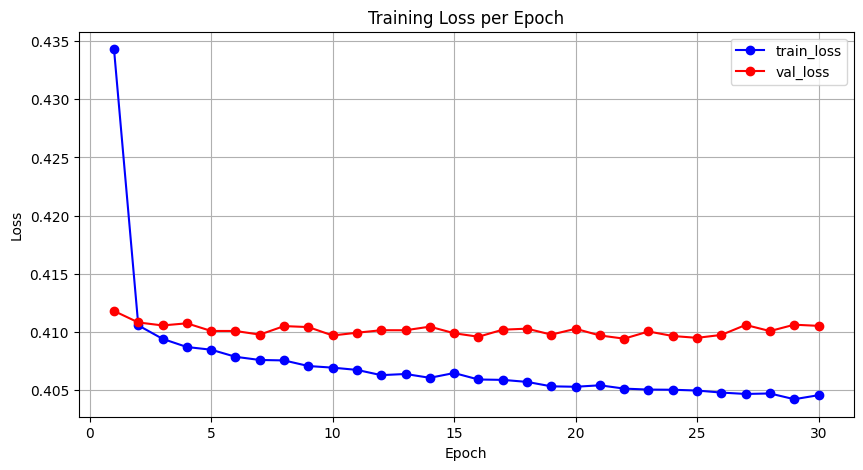

In [83]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [84]:
def calculate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)  # shape: [batch_size, num_classes]
            _, predicted = torch.max(outputs, 1)  # get index of max logit
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy:.2f}%')
print(f'Validation Accuracy: {val_accuracy:.2f}%')

Training Accuracy: 82.43%
Validation Accuracy: 82.07%


In [85]:
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)  # First hidden layer with 4 neurons
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.61)

        self.fc2 = nn.Linear(128, 16)  # Second hidden layer with 3 neurons
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.1)

        self.fc3 = nn.Linear(16, 3)  # Output layer with 3 neurons (for 3 sentiment classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)  # raw logits for CrossEntropyLoss
        return x


In [87]:
model = ANNModel(input_size=train_vectors.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [88]:
num_epochs = 10  # Number of epochs
losses = []  # List to store the average loss per epoch
val_losses = []

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0  # Variable to store the total loss in each epoch
    total_val_loss = 0
    count = 0  # Variable to count the number of batches
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()  # Squeeze the output to match the label's shape
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count  # Calculate average loss for the epoch
    losses.append(average_loss)  # Append average loss to the list
       
    for inputs, labels in val_loader:
        val_outputs = model(inputs)
        val_outputs = val_outputs.squeeze()  # Squeeze the output to match the label's shape
        val_loss = criterion(val_outputs, labels)
        total_val_loss += val_loss.item()
        val_count += 1
    average_val_loss = total_val_loss / val_count  # Calculate average loss for the epoch
    val_losses.append(average_val_loss)  # Append average loss to the list
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')

Epoch 1/10, Loss: 0.4362, Val Loss: 0.4096
Epoch 2/10, Loss: 0.4069, Val Loss: 0.4074
Epoch 3/10, Loss: 0.4040, Val Loss: 0.4052
Epoch 4/10, Loss: 0.4014, Val Loss: 0.4052
Epoch 5/10, Loss: 0.3995, Val Loss: 0.4040
Epoch 6/10, Loss: 0.3976, Val Loss: 0.4036
Epoch 7/10, Loss: 0.3959, Val Loss: 0.4031
Epoch 8/10, Loss: 0.3944, Val Loss: 0.4039
Epoch 9/10, Loss: 0.3933, Val Loss: 0.4040
Epoch 10/10, Loss: 0.3919, Val Loss: 0.4040


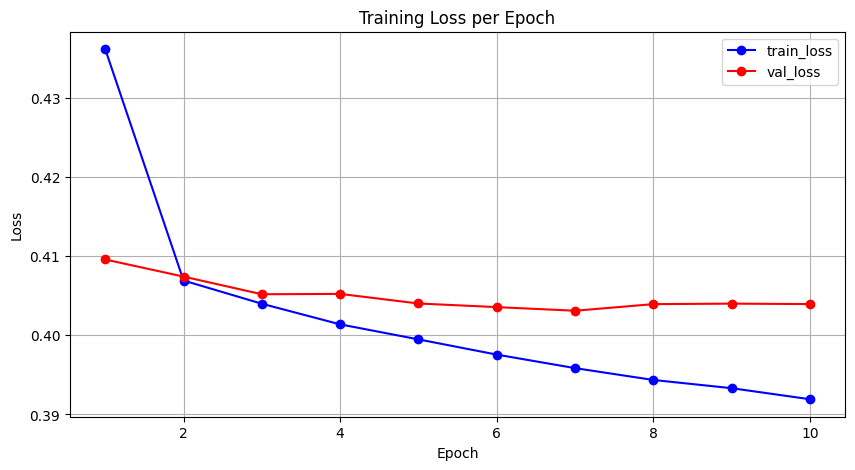

In [89]:
# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-', color='b', label = 'train_loss')
plt.plot(range(1, num_epochs + 1), val_losses, marker='o', linestyle='-', color='r', label = 'val_loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [90]:
def calculate_accuracy(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)  # shape: [batch_size, num_classes]
            _, predicted = torch.max(outputs, 1)  # get index of max logit
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


train_accuracy = calculate_accuracy(train_loader)
val_accuracy = calculate_accuracy(val_loader)

print(f'Training Accuracy: {train_accuracy:.2f}%')
print(f'Validation Accuracy: {val_accuracy:.2f}%')

Training Accuracy: 83.29%
Validation Accuracy: 82.20%
